## **Análise Exploratória de Dados (EDA) — Evasão Escolar**

Este notebook explora o dataset para entender:
- Distribuição da variável-alvo (desbalanceamento)
- Perfil demográfico e socioeconômico dos alunos
- Relações entre features e evasão
- Matriz de correlação

Todas as figuras são salvas em `../figures/` para uso no README e futuros relatórios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Caminhos
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Paleta e estilo consistentes
PALETTE      = {'Evadiu': '#E74C3C', 'Não Evadiu': '#2ECC71'}
COLOR_MAIN   = '#2C3E50'
COLOR_ACCENT = '#E74C3C'
COLOR_OK     = '#2ECC71'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'     : 150,
    'figure.facecolor': 'white',
    'axes.facecolor' : 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family'    : 'DejaVu Sans',
})

def save_fig(name: str):
    """Salva figura atual em alta resolução."""
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')

In [2]:
df = pd.read_csv(DATA_DIR / 'evasao_escolar.csv')
print(f'Shape: {df.shape}')
print(f'Tipos:\n{df.dtypes}')
df.head()

Shape: (15000, 15)
Tipos:
idade                      int64
sexo                      object
raca_cor                  object
serie                     object
turno                     object
nota_portugues           float64
nota_matematica          float64
distorcao_idade_serie      int64
faltas_anuais              int64
repeticoes_anteriores      int64
trabalha                   int64
renda_familiar             int64
escolaridade_pai           int64
escolaridade_mae           int64
evasao                     int64
dtype: object


,idade,sexo,raca_cor,serie,turno,nota_portugues,nota_matematica,distorcao_idade_serie,faltas_anuais,repeticoes_anteriores,trabalha,renda_familiar,escolaridade_pai,escolaridade_mae,evasao
0,17,F,Preta,3ano,matutino,7.06,6.36,0,11,0,0,615,3,0,0
1,16,M,Parda,2ano,matutino,1.63,4.07,0,8,0,0,887,3,3,1
2,17,M,Branca,3ano,matutino,5.46,5.37,0,5,0,0,1327,2,0,0
3,16,M,Branca,2ano,noturno,9.13,6.69,0,14,0,1,1847,2,0,0
4,16,M,Branca,1ano,vespertino,4.46,8.83,1,13,0,0,734,0,1,0


## **Qualidade dos Dados:**

In [3]:
print('=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas descritivas ===')
df.describe().round(2)

=== Valores nulos ===
idade                    0
sexo                     0
raca_cor                 0
serie                    0
turno                    0
nota_portugues           0
nota_matematica          0
distorcao_idade_serie    0
faltas_anuais            0
repeticoes_anteriores    0
trabalha                 0
renda_familiar           0
escolaridade_pai         0
escolaridade_mae         0
evasao                   0
dtype: int64

=== Estatísticas descritivas ===


,idade,nota_portugues,nota_matematica,distorcao_idade_serie,faltas_anuais,repeticoes_anteriores,trabalha,renda_familiar,escolaridade_pai,escolaridade_mae,evasao
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,16.54,6.00,5.82,0.62,13.94,0.16,0.42,1690.91,1.11,1.21,0.26
std,1.17,1.95,2.04,0.84,4.72,0.38,0.49,1584.41,1.00,1.00,0.44
min,15.00,0.00,0.00,0.00,1.00,0.00,0.00,500.00,0.00,0.00,0.00
25%,16.00,4.68,4.41,0.00,11.00,0.00,0.00,699.00,0.00,0.00,0.00
50%,16.00,6.02,5.82,0.00,14.00,0.00,0.00,1196.00,1.00,1.00,0.00
75%,17.00,7.36,7.24,1.00,17.00,0.00,1.00,2073.00,2.00,2.00,1.00
max,22.00,10.00,10.00,5.00,33.00,2.00,1.00,20000.00,3.00,3.00,1.00


## **Target: Evasão**

Salvo: ..\figures\01_distribuicao_target.png


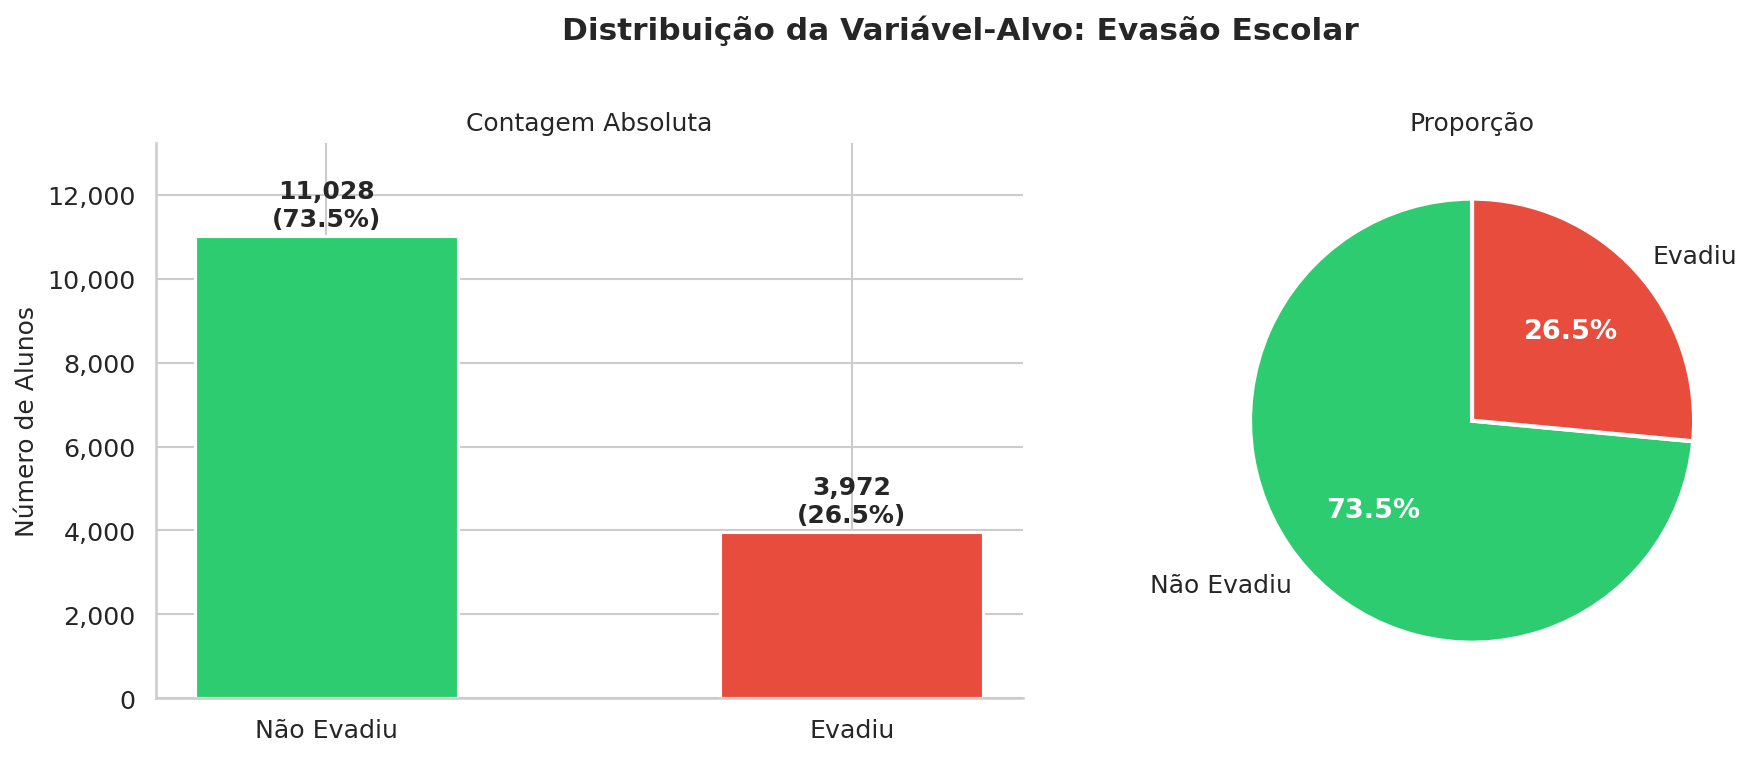

In [4]:
contagem = df['evasao'].value_counts()
rotulos  = ['Não Evadiu', 'Evadiu']
cores    = [COLOR_OK, COLOR_ACCENT]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição da Variável-Alvo: Evasão Escolar',
             fontsize=15, fontweight='bold', y=1.01)

# Barras
ax = axes[0]
bars = ax.bar(rotulos, contagem.values, color=cores,
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, contagem.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Alunos', fontsize=12)
ax.set_ylim(0, max(contagem.values) * 1.20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.set_title('Contagem Absoluta', fontsize=12)

# Pizza
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    contagem.values, labels=rotulos, colors=cores,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12})
for at in autotexts:
    at.set(fontsize=13, fontweight='bold', color='white')
ax.set_title('Proporção', fontsize=12)

plt.tight_layout()
save_fig('01_distribuicao_target')
plt.show()

---
## **Evasão por Variáveis Categóricas:**

Salvo: ..\figures\02_evasao_por_categorias.png


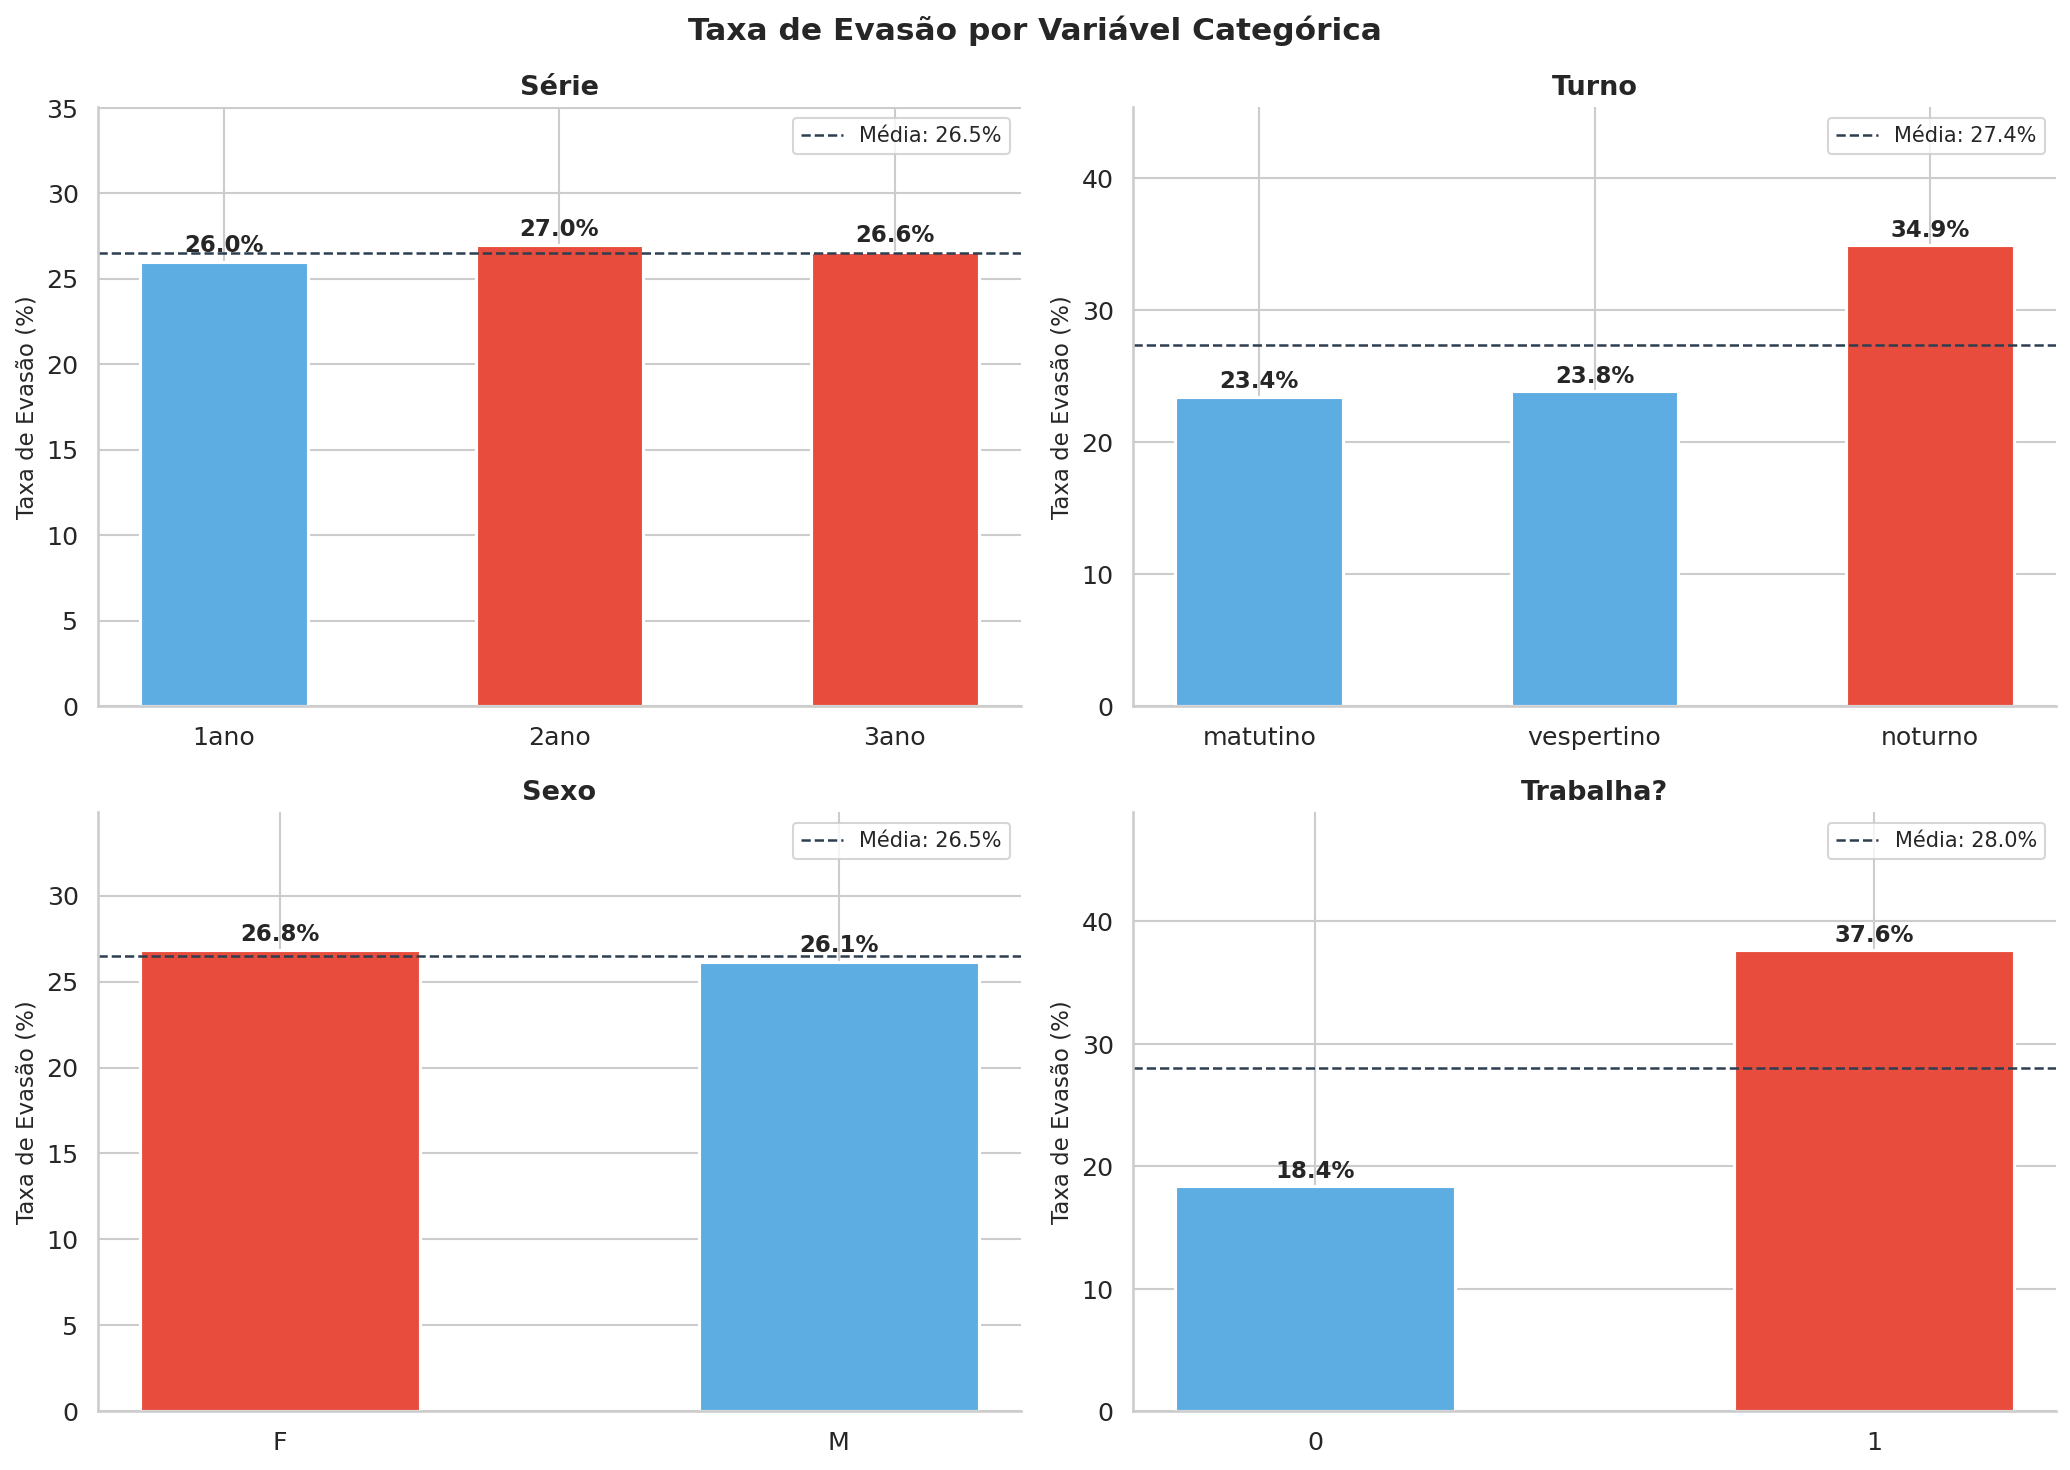

In [5]:
cats = [
    ('serie',  'Série',           ['1ano', '2ano', '3ano']),
    ('turno',  'Turno',           ['matutino', 'vespertino', 'noturno']),
    ('sexo',   'Sexo',            ['F', 'M']),
    ('trabalha', 'Trabalha?',     [0, 1]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Taxa de Evasão por Variável Categórica',
             fontsize=15, fontweight='bold')

for ax, (col, titulo, ordem) in zip(axes.ravel(), cats):
    taxas = (df.groupby(col)['evasao'].mean() * 100).reindex(ordem)

    bars = ax.bar(taxas.index.astype(str), taxas.values,
                  color=[COLOR_ACCENT if v > taxas.mean() else '#5DADE2'
                         for v in taxas.values],
                  width=0.5, edgecolor='white', linewidth=1.5)

    # Linha da média
    media = taxas.mean()
    ax.axhline(media, color=COLOR_MAIN, linestyle='--', linewidth=1.2,
               label=f'Média: {media:.1f}%')

    for bar, val in zip(bars, taxas.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel('Taxa de Evasão (%)', fontsize=11)
    ax.set_ylim(0, taxas.max() * 1.3)
    ax.legend(fontsize=10)

plt.tight_layout()
save_fig('02_evasao_por_categorias')
plt.show()

---
## **Distorção Idade-Série (Principal Preditor):**

Salvo: ..\figures\03_distorcao_idade_serie.png


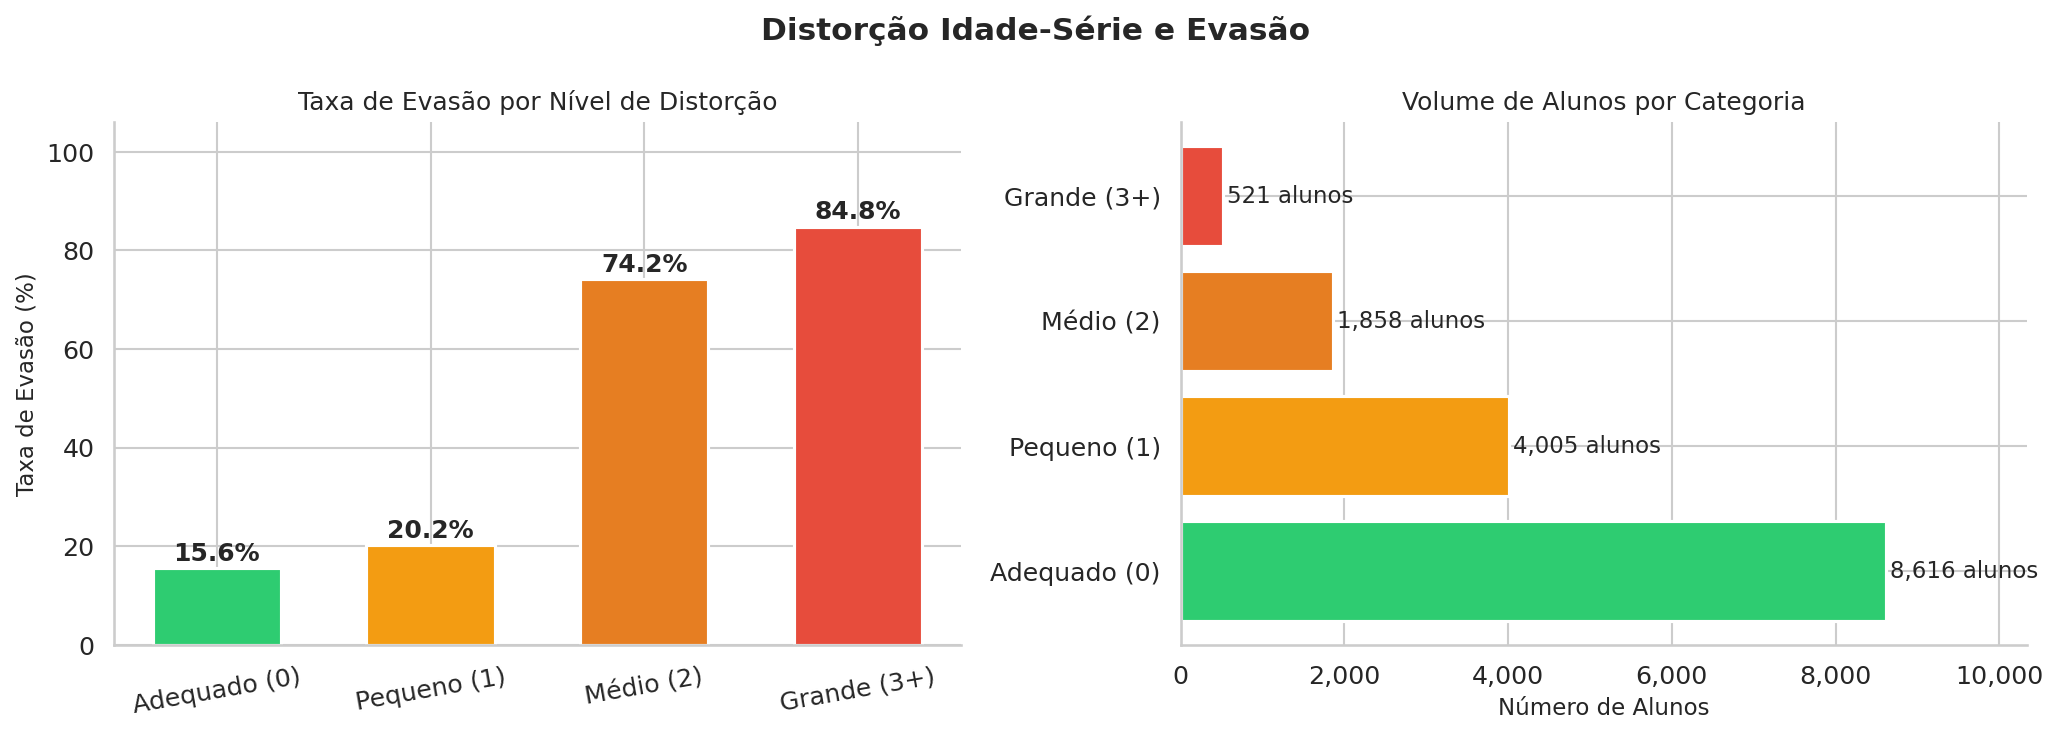

In [6]:
bins_distorcao = [-0.1, 0, 1, 2, 5]
labels_distorcao = ['Adequado (0)', 'Pequeno (1)', 'Médio (2)', 'Grande (3+)']
df['cat_distorcao'] = pd.cut(df['distorcao_idade_serie'],
                              bins=bins_distorcao, labels=labels_distorcao)

taxas_dist = df.groupby('cat_distorcao', observed=True)['evasao'].mean() * 100
counts_dist = df['cat_distorcao'].value_counts().reindex(labels_distorcao)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distorção Idade-Série e Evasão',
             fontsize=15, fontweight='bold')

# Taxa de evasão por categoria
ax = axes[0]
cores_dist = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars = ax.bar(labels_distorcao, taxas_dist.values,
              color=cores_dist, width=0.6, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, taxas_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Taxa de Evasão por Nível de Distorção', fontsize=12)
ax.set_ylabel('Taxa de Evasão (%)', fontsize=11)
ax.set_ylim(0, taxas_dist.max() * 1.25)
ax.tick_params(axis='x', rotation=10)

# Distribuição dos alunos por categoria
ax = axes[1]
ax.barh(labels_distorcao, counts_dist.values,
        color=cores_dist, edgecolor='white', linewidth=1.5)
for i, (val, cat) in enumerate(zip(counts_dist.values, labels_distorcao)):
    ax.text(val + 50, i, f'{val:,} alunos', va='center', fontsize=11)
ax.set_title('Volume de Alunos por Categoria', fontsize=12)
ax.set_xlabel('Número de Alunos', fontsize=11)
ax.set_xlim(0, counts_dist.max() * 1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save_fig('03_distorcao_idade_serie')
plt.show()

## **Distribuição de Notas e Faltas por Evasão:**

Salvo: ..\figures\04_distribuicoes_continuas.png


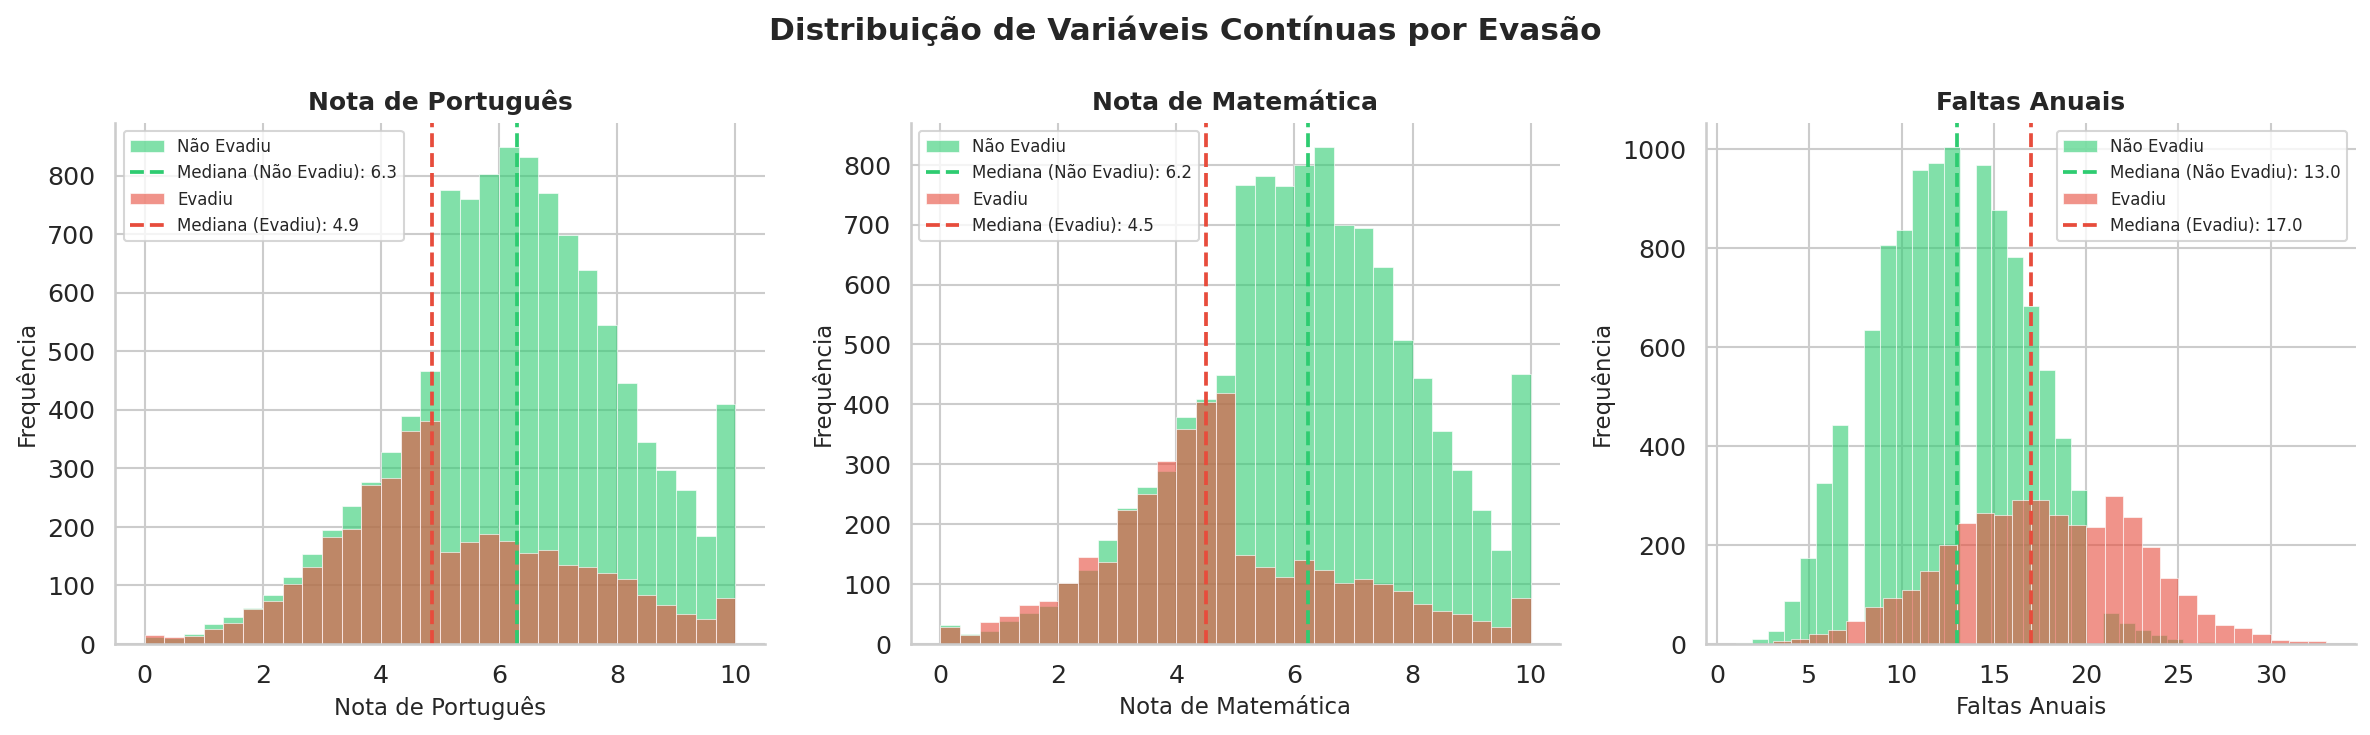

In [7]:
df['evasao_label'] = df['evasao'].map({0: 'Não Evadiu', 1: 'Evadiu'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição de Variáveis Contínuas por Evasão',
             fontsize=15, fontweight='bold')

variaveis = [
    ('nota_portugues', 'Nota de Português'),
    ('nota_matematica', 'Nota de Matemática'),
    ('faltas_anuais', 'Faltas Anuais'),
]

for ax, (col, titulo) in zip(axes, variaveis):
    for label, cor in [('Não Evadiu', COLOR_OK), ('Evadiu', COLOR_ACCENT)]:
        subset = df[df['evasao_label'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=cor, label=label,
                edgecolor='white', linewidth=0.5)
        ax.axvline(subset.median(), color=cor, linestyle='--',
                   linewidth=1.8, label=f'Mediana ({label}): {subset.median():.1f}')

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel(titulo, fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig('04_distribuicoes_continuas')
plt.show()

## **Matriz de Correlação:**

Salvo: ..\figures\05_matriz_correlacao.png


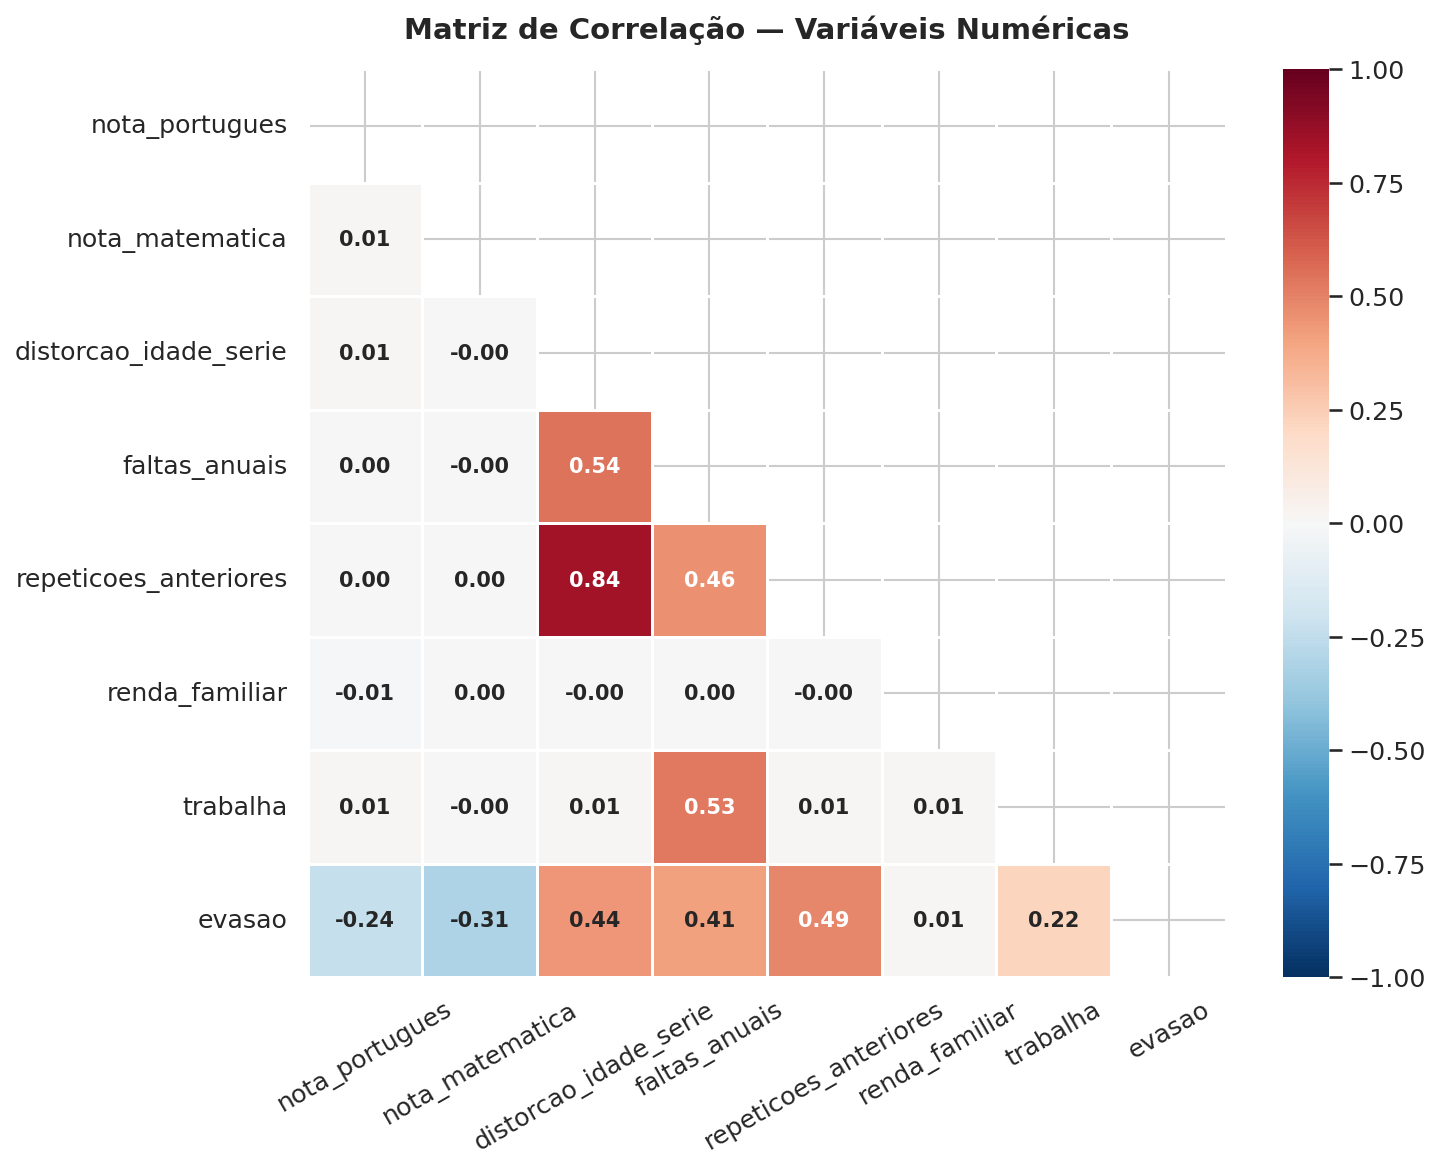


Correlações com evasão:
repeticoes_anteriores    0.49
distorcao_idade_serie    0.44
faltas_anuais            0.41
nota_matematica         -0.31
nota_portugues          -0.24
trabalha                 0.22
renda_familiar           0.01
Name: evasao, dtype: float64


In [8]:
num_cols = ['nota_portugues', 'nota_matematica', 'distorcao_idade_serie',
            'faltas_anuais', 'repeticoes_anteriores', 'renda_familiar',
            'trabalha', 'evasao']

corr = df[num_cols].corr().round(2)

# Máscara para triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_fig('05_matriz_correlacao')
plt.show()

# Correlações com evasão ordenadas
print('\nCorrelações com evasão:')
print(corr['evasao'].drop('evasao').sort_values(key=abs, ascending=False))

## **Boxplots: Notas por Série e Evasão:**

Salvo: ..\figures\06_boxplot_notas_serie.png


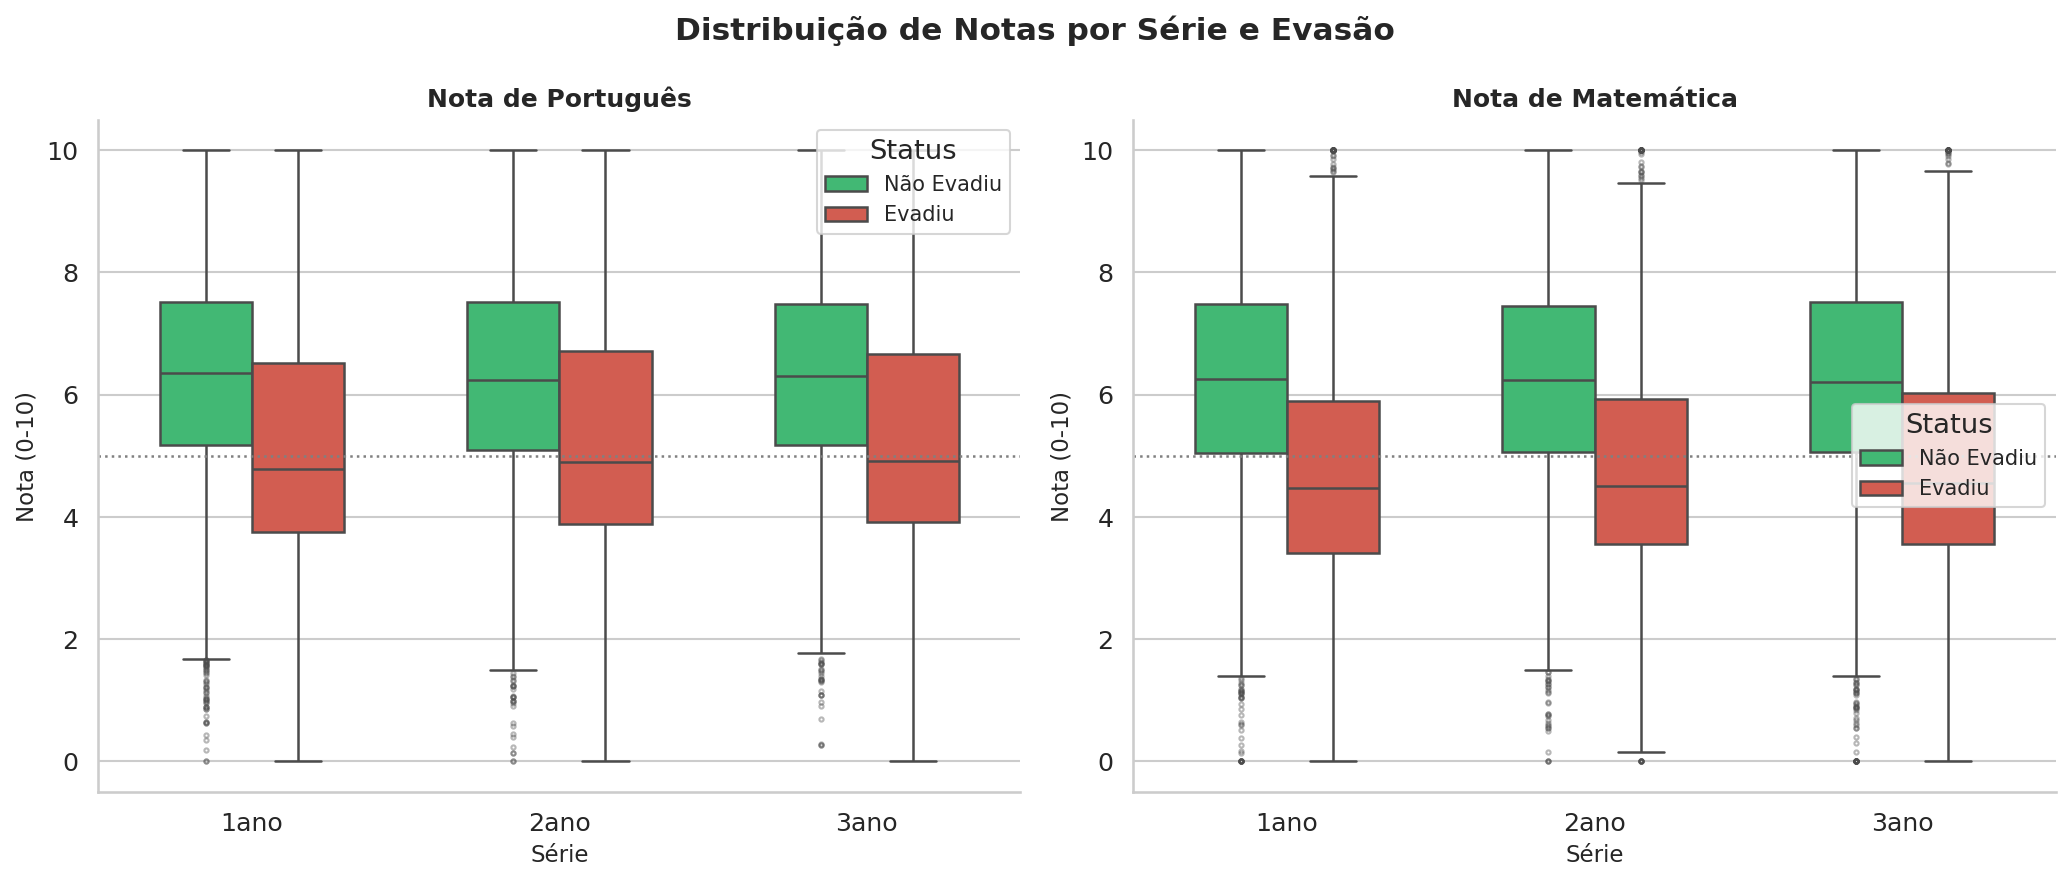

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribuição de Notas por Série e Evasão',
             fontsize=15, fontweight='bold')

for ax, col, titulo in zip(axes,
                            ['nota_portugues', 'nota_matematica'],
                            ['Nota de Português', 'Nota de Matemática']):
    sns.boxplot(
        data=df, x='serie', y=col, hue='evasao_label',
        palette={'Não Evadiu': COLOR_OK, 'Evadiu': COLOR_ACCENT},
        order=['1ano', '2ano', '3ano'],
        width=0.6, linewidth=1.2,
        flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.4},
        ax=ax
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Série', fontsize=11)
    ax.set_ylabel('Nota (0-10)', fontsize=11)
    ax.legend(title='Status', fontsize=10)
    ax.axhline(5, color='gray', linestyle=':', linewidth=1.2,
               label='Limiar de aprovação (5.0)')

plt.tight_layout()
save_fig('06_boxplot_notas_serie')
plt.show()

---
## **Resumo dos Insights:**

In [10]:
taxa_geral       = df['evasao'].mean() * 100
taxa_noturno     = df[df['turno'] == 'noturno']['evasao'].mean() * 100
taxa_matutino    = df[df['turno'] == 'matutino']['evasao'].mean() * 100
taxa_grande_dist = df[df['distorcao_idade_serie'] >= 3]['evasao'].mean() * 100
taxa_sem_dist    = df[df['distorcao_idade_serie'] == 0]['evasao'].mean() * 100
taxa_1ano        = df[df['serie'] == '1ano']['evasao'].mean() * 100
taxa_3ano        = df[df['serie'] == '3ano']['evasao'].mean() * 100

print(f"""
╔══════════════════════════════════════════════════════╗
║          PRINCIPAIS INSIGHTS DA EDA                  ║
╠══════════════════════════════════════════════════════╣
║  Taxa de evasão geral        : {taxa_geral:5.1f}%               ║
╠══════════════════════════════════════════════════════╣
║  TURNO                                               ║
║   Noturno                    : {taxa_noturno:5.1f}%               ║
║   Matutino                   : {taxa_matutino:5.1f}%               ║
╠══════════════════════════════════════════════════════╣
║  DISTORÇÃO IDADE-SÉRIE                               ║
║   Grande atraso (3+ anos)    : {taxa_grande_dist:5.1f}%               ║
║   Sem distorção              : {taxa_sem_dist:5.1f}%               ║
╠══════════════════════════════════════════════════════╣
║  SÉRIE                                               ║
║   1º ano (maior risco)       : {taxa_1ano:5.1f}%               ║
║   3º ano                     : {taxa_3ano:5.1f}%               ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║          PRINCIPAIS INSIGHTS DA EDA                  ║
╠══════════════════════════════════════════════════════╣
║  Taxa de evasão geral        :  26.5%               ║
╠══════════════════════════════════════════════════════╣
║  TURNO                                               ║
║   Noturno                    :  34.9%               ║
║   Matutino                   :  23.4%               ║
╠══════════════════════════════════════════════════════╣
║  DISTORÇÃO IDADE-SÉRIE                               ║
║   Grande atraso (3+ anos)    :  84.8%               ║
║   Sem distorção              :  15.6%               ║
╠══════════════════════════════════════════════════════╣
║  SÉRIE                                               ║
║   1º ano (maior risco)       :  26.0%               ║
║   3º ano                     :  26.6%               ║
╚══════════════════════════════════════════════════════╝

